In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df=sns.load_dataset("titanic")

In [3]:
print(df.head())
print(df.shape)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
(891, 15)


<Axes: >

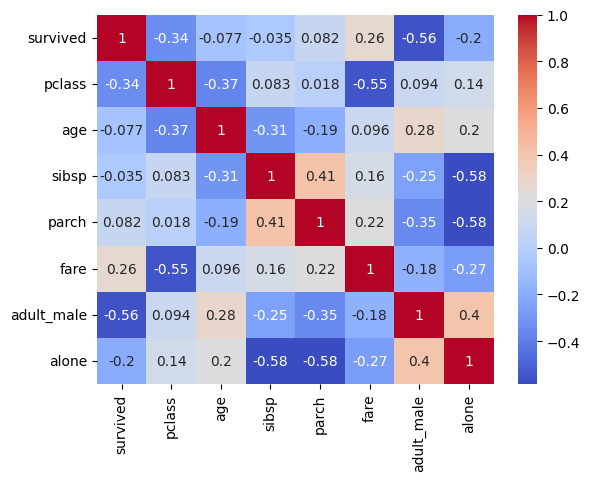

In [10]:
correlation_matrix=df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm")

In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

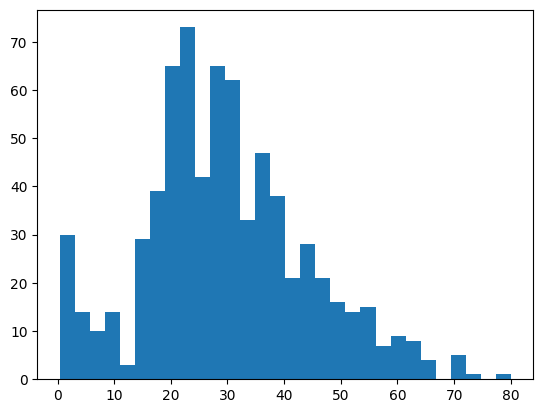

In [43]:
plt.hist(df["age"],bins=30)
plt.show()

### Because the histogram of age was skewed , it was best to replace the nan values with median,we can drop deck too because of more than 2/3 or the data being nan, also because plass is the same as class , similarly embarked and embark_town , so we would drop that column too.

In [11]:
df["age"]=df["age"].fillna(df.groupby("sex")["age"].transform("median"))

In [12]:
df.drop(["embark_town"],axis=1,inplace=True)
df.drop(["deck"],axis=1,inplace=True)
df.drop(["pclass"],axis=1,inplace=True)

In [13]:
df.drop(["alive"],axis=1,inplace=True)

In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

survived      0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alone         0
dtype: int64

In [16]:
df[df["age"]>=100]

,survived,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone


In [17]:
X=df.drop("survived",axis=1)
Y=df["survived"]

In [18]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

In [19]:
x_val,x_test,y_val,y_test=train_test_split(x_test,y_test,test_size=0.5,random_state=42)

In [20]:
x_train["adult_male"]=x_train["adult_male"].map({True:1,False:2})
x_val["adult_male"]=x_val["adult_male"].map({True:1,False:2})
x_test["adult_male"]=x_test["adult_male"].map({True:1,False:2})

In [21]:
x_train["alone"]=x_train["alone"].map({True:1,False:2})
x_val["alone"]=x_val["alone"].map({True:1,False:2})
x_test["alone"]=x_test["alone"].map({True:1,False:2})

In [22]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop="first")

In [23]:
x_train_new=ohe.fit_transform(x_train.loc[:,["sex","embarked","who","class"]]).toarray()
x_val_new=ohe.transform(x_val.loc[:,["sex","embarked","who","class"]]).toarray()
x_test_new=ohe.transform(x_test.loc[:,["sex","embarked","who","class"]]).toarray()

In [24]:
x_train_new[1]

array([0., 0., 1., 0., 1., 0., 1.])

In [25]:
x_train.drop(columns=["sex","class","who","embarked"],axis=1,inplace=True)
x_val.drop(columns=["sex","class","who","embarked"],axis=1,inplace=True)
x_test.drop(columns=["sex","class","who","embarked"],axis=1,inplace=True)

In [26]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

In [27]:
x_train=ss.fit_transform(x_train)
x_val=ss.transform(x_val)
x_test=ss.transform(x_test)

In [28]:
x_train[0]

array([ 0.40764443,  0.4209213 , -0.48411249,  1.12477566,  1.24047391,
        1.20768292])

In [29]:
x_train=np.hstack((x_train,x_train_new))
x_val=np.hstack((x_val,x_val_new))
x_test=np.hstack((x_test,x_test_new))

In [30]:
x_train[0]

array([ 0.40764443,  0.4209213 , -0.48411249,  1.12477566,  1.24047391,
        1.20768292,  0.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  0.        ])

In [39]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

model_0 = Sequential([
    Dense(16, activation="relu", input_shape=(x_train.shape[1],)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_0.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_0.fit(x_train, y_train, batch_size=32, epochs=20)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3955 - loss: 0.7297
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5289 - loss: 0.6857 
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6447 - loss: 0.6537 
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6608 - loss: 0.6296 
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6704 - loss: 0.6103 
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6801 - loss: 0.5949 
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6961 - loss: 0.5815
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7074 - loss: 0.5701 
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7090 - loss: 0.5594 
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7138 - loss: 0.5499
Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7315 - loss: 0.5411
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.73

In [40]:
model_0.evaluate(x_val,y_val)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8195 - loss: 0.4703 


[0.47028684616088867, 0.8195488452911377]

In [41]:
predictions=model_0.predict(x_test)
y_preds=(predictions>0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [45]:
from sklearn.metrics import precision_score ,recall_score ,roc_auc_score ,roc_curve

In [44]:
roc_auc=roc_auc_score(y_test,predictions)
precision=precision_score(y_test,y_preds)
recall=recall_score(y_test,y_preds)
print(f"Roc Auc is :{roc_auc} | Precision score is : {precision} | Recall score is : {recall}")

Roc Auc is :0.853482413230841 | Precision score is : 0.8085106382978723 | Recall score is : 0.7169811320754716


In [46]:
fpr , tpr , threshold = roc_curve(y_test,predictions)

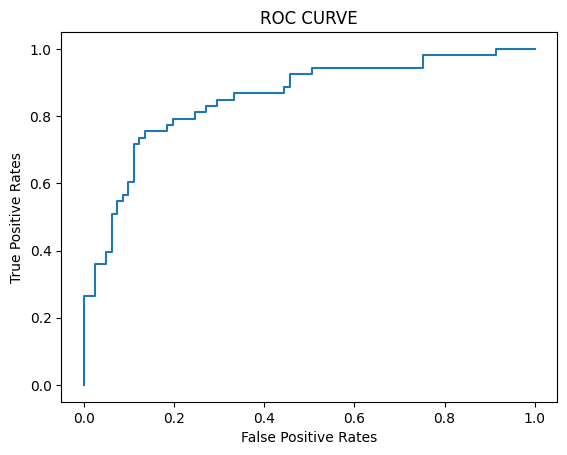

In [48]:
plt.plot(fpr,tpr)
plt.xlabel("False Positive Rates")
plt.ylabel("True Positive Rates")
plt.title("ROC CURVE")
plt.show()